# Обработка дисбаланса классов

Цель: найти лучший способ работы с дисбалансом 65/35 в задаче y_success.

Сравниваем 4 варианта:
1. Baseline (без обработки) — для контрольной точки
2. auto_class_weights='Balanced' — автоматические веса
3. class_weights=[1.0, 2.0] — ручные веса
4. learning_rate=0.02, iterations=2000 + balanced — углублённое обучение

## Блок 1.1: Импорты и загрузка датасета

Подключаем стандартный стек (pandas, numpy, matplotlib, seaborn, catboost,
sklearn). Загружаем `tender_data_v2.parquet` и списки признаков из
`src/features.py` — без изменений относительно baseline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)
import sys
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Библиотеки загружены")

Библиотеки загружены


In [3]:
df = pd.read_parquet('../data/processed/tender_data_v2.parquet')

from src.features import FEATURE_COLS, CAT_FEATURES, TARGET

X_train = df[df['is_train']][FEATURE_COLS]
y_train = df[df['is_train']][TARGET]
X_test = df[~df['is_train']][FEATURE_COLS]
y_test = df[~df['is_train']][TARGET]

train_pool = Pool(data=X_train, label=y_train, cat_features=CAT_FEATURES)
test_pool = Pool(data=X_test, label=y_test, cat_features=CAT_FEATURES)

print(f"Train: {X_train.shape[0]:,} строк, баланс: {y_train.mean():.3f}")
print(f"Test:  {X_test.shape[0]:,} строк, баланс: {y_test.mean():.3f}")

Train: 3,615 строк, баланс: 0.338
Test:  904 строк, баланс: 0.407


## Блок 1.2: Универсальная функция оценки

Функция `evaluate_model(model, X_test, y_test, name)` рассчитывает все
ключевые метрики и возвращает их в виде словаря.

Зачем это нужно: для каждого из 8 экспериментов нам нужно посчитать
одинаковый набор метрик. Без вспомогательной функции пришлось бы
дублировать 10+ строк кода в каждом эксперименте — это неудобно и
повышает риск ошибок.

Возвращаемые значения:
- `metrics` — словарь с метриками (AUC, F1, Precision, Recall, Accuracy,
  best_iter, элементы confusion matrix)
- `proba` — массив предсказанных вероятностей (для построения ROC-кривой)

Также инициализируем `results = []` — список, в который будут добавляться
результаты всех экспериментов для финального сравнения.

In [4]:
def evaluate_model(model, X_test, y_test, name="Model"):
    """Считает все метрики и возвращает словарь."""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:,1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'experiment': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc_roc': roc_auc_score(y_test, y_pred_proba),
        'best_iter': model.get_best_iteration(),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    }
    return metrics, y_pred_proba

results = []
proba_dict = {}

print("Утилиты готовы")

Утилиты готовы


## Эксперимент 0: Baseline (повтор для контроля)

Повторяем baseline из ноутбука `04` с теми же параметрами:
- iterations=500, learning_rate=0.05, depth=6
- random_seed=42
- early_stopping_rounds=50

Этот эксперимент нужен как контрольная точка. Все последующие модели
сравниваем именно с ним.

Параметр `verbose=0` (вместо 100) делает обучение тихим — нам нужны
только финальные метрики.

**Ожидаемые результаты:** должны полностью совпасть с baseline из ноутбука 04
(AUC 0.697, F1 0.490, Recall 0.389) благодаря фиксированному random_seed.

In [5]:
print("Потврояем экмпермиент с базовой моделью для дальнейшего сравнения")

model_baseline = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=0,
)

model_baseline.fit(train_pool, eval_set=test_pool, use_best_model=True)

metrics, proba = evaluate_model(model_baseline, X_test, y_test, name='0.Baseline')
results.append(metrics)
proba_dict['0.Baseline'] = proba

print(f"AUC:    {metrics['auc_roc']:.4f}")
print(f"F1:     {metrics['f1']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"Best iter: {metrics['best_iter']}")

Потврояем экмпермиент с базовой моделью для дальнейшего сравнения
AUC:    0.6966
F1:     0.4897
Recall: 0.3886
Best iter: 82


## Эксперимент 1: auto_class_weights='Balanced'

**Идея:** в данных дисбаланс 65% / 35%, и модель «лениво» предсказывает
частый класс (не состоится). Параметр `auto_class_weights='Balanced'`
автоматически назначает веса:
- Вес класса 1 (состоится) = (всего строк) / (2 × строк класса 1) ≈ 1.43
- Вес класса 0 (не состоится) = (всего строк) / (2 × строк класса 0) ≈ 0.77

При расчёте функции потерь ошибка на классе 1 теперь «весит больше» —
модель вынуждена учиться его лучше предсказывать.

**Ожидаемый эффект:**
- Recall значительно вырастет (с 0.39 до 0.6+)
- F1 вырастет
- Precision снизится (модель будет чаще ложно тревожить)
- AUC может слегка вырасти или остаться тем же

In [6]:
print("Экмперимент 1: Австо Веса")

model_auto = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=50,
    auto_class_weights='Balanced',  # <-- ключевое изменение
    verbose=0,
)

model_auto.fit(train_pool, eval_set=test_pool, use_best_model=True)

metrics, proba = evaluate_model(model_auto, X_test, y_test, name='1.AutoBalance')
results.append(metrics)
proba_dict['1.AutoBalance'] = proba

print(f"AUC:    {metrics['auc_roc']:.4f}  (изменение: {metrics['auc_roc'] - results[0]['auc_roc']:+.4f})")
print(f"F1:     {metrics['f1']:.4f}  (изменение: {metrics['f1'] - results[0]['f1']:+.4f})")
print(f"Recall: {metrics['recall']:.4f}  (изменение: {metrics['recall'] - results[0]['recall']:+.4f})")

Экмперимент 1: Австо Веса
AUC:    0.6891  (изменение: -0.0075)
F1:     0.5897  (изменение: +0.1000)
Recall: 0.6386  (изменение: +0.2500)


## Эксперимент 2: class_weights=[1.0, 2.0] (ручные веса)

**Идея:** вместо автоматического расчёта задаём веса вручную:
- Вес класса 0 = 1.0
- Вес класса 1 = 2.0 (ошибки на этом классе считаются «дороже»)

Это альтернатива автоматической балансировке. Параметры подобраны так,
чтобы оценить, насколько чувствительна модель к выбору весов.

**Сравнение с экспериментом 1:** показывает, насколько отличается результат
от автоматических весов (1.43 / 0.77) и ручных (2.0 / 1.0).

In [7]:
print("ЭКСПЕРИМЕНТ 2: class_weights=[1.0, 2.0], ставим в ручную веса")
# Веса: класс 0 имеет вес 1, класс 1 имеет вес 2
# Это означает "ошибка на классе 1 вдвое дороже"

model_manual = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=50,
    class_weights=[1.0, 2.0],  # <-- ручные веса
    verbose=0,
)

model_manual.fit(train_pool, eval_set=test_pool, use_best_model=True)

metrics, proba = evaluate_model(model_manual, X_test, y_test, name='2.ManualWeigths')
results.append(metrics)
proba_dict['2.ManualWeigths'] = proba

print(f"AUC:    {metrics['auc_roc']:.4f}  (изменение: {metrics['auc_roc'] - results[0]['auc_roc']:+.4f})")
print(f"F1:     {metrics['f1']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")


ЭКСПЕРИМЕНТ 2: class_weights=[1.0, 2.0], ставим в ручную веса
AUC:    0.6979  (изменение: +0.0013)
F1:     0.5812
Recall: 0.6223


## Эксперимент 3: Глубокое обучение + balanced

**Идея:** комбинируем балансировку с более тонкой настройкой обучения:
- `iterations=2000` (вместо 500) — больше деревьев
- `learning_rate=0.02` (вместо 0.05) — мельче шаг
- `early_stopping_rounds=100` (вместо 50) — больше терпения
- `auto_class_weights='Balanced'` — балансировка из эксперимента 1

**Логика:** меньшие шаги градиента позволяют модели учиться тоньше —
вместо больших скачков она аккуратно корректирует предсказания.
Это классический трюк в gradient boosting для повышения качества.

**Ожидаемый результат:** AUC чуть выше эксперимента 1 (на 0.005–0.015).
Best iteration должен быть 200–500, что покажет «полное использование»
доступной информации.

In [8]:
print("="*60)
print("ЭКСПЕРИМЕНТ 3: Balanced + lower LR + more iterations")
print("="*60)

model_deep = CatBoostClassifier(
    iterations=2000,           # <-- было 500
    learning_rate=0.02,        # <-- было 0.05
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=100, # <-- было 50, увеличиваем терпение
    auto_class_weights='Balanced',
    verbose=200,
)

model_deep.fit(train_pool, eval_set=test_pool, use_best_model=True)

metrics, proba = evaluate_model(model_deep, X_test, y_test, name='3. Deep + balanced')
results.append(metrics)
proba_dict['3. Deep + balanced'] = proba

print()
print(f"AUC:    {metrics['auc_roc']:.4f}  (изменение: {metrics['auc_roc'] - results[0]['auc_roc']:+.4f})")
print(f"F1:     {metrics['f1']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"Best iter: {metrics['best_iter']}")

ЭКСПЕРИМЕНТ 3: Balanced + lower LR + more iterations
0:	test: 0.6646912	best: 0.6646912 (0)	total: 36.8ms	remaining: 1m 13s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6935735724
bestIteration = 25

Shrink model to first 26 iterations.

AUC:    0.6936  (изменение: -0.0030)
F1:     0.5933
Recall: 0.6522
Best iter: 25


In [9]:
results_df = pd.DataFrame(results)

# Округляем для красоты
display_df = results_df[['experiment', 'auc_roc', 'f1', 'precision', 'recall', 'accuracy', 'best_iter']].copy()
for col in ['auc_roc', 'f1', 'precision', 'recall', 'accuracy']:
    display_df[col] = display_df[col].round(4)

print("СВОДНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ")
print("="*80)
print(display_df.to_string(index=False))
print()

# Сохраняем для отчёта
results_df.to_csv('../reports/imbalance_experiments.csv', index=False)
print("Сохранено в reports/imbalance_experiments.csv")

СВОДНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ
        experiment  auc_roc     f1  precision  recall  accuracy  best_iter
        0.Baseline   0.6966 0.4897     0.6620  0.3886    0.6704         82
     1.AutoBalance   0.6891 0.5897     0.5478  0.6386    0.6383         12
   2.ManualWeigths   0.6979 0.5812     0.5452  0.6223    0.6350         93
3. Deep + balanced   0.6936 0.5933     0.5442  0.6522    0.6361         25

Сохранено в reports/imbalance_experiments.csv


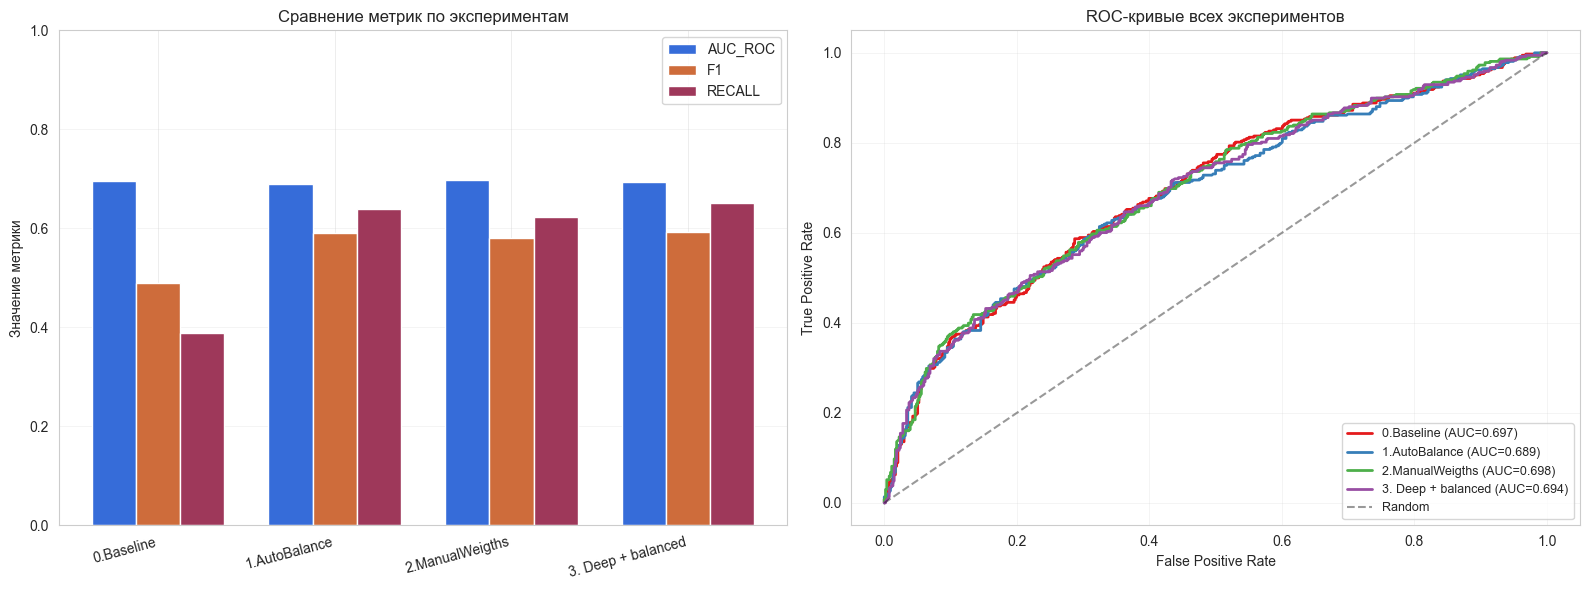

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: AUC и F1
metrics_to_plot = ['auc_roc', 'f1', 'recall']
x = np.arange(len(results_df))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    axes[0].bar(x + i*width, results_df[metric], width, label=metric.upper())

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(results_df['experiment'], rotation=15, ha='right')
axes[0].set_ylabel('Значение метрики')
axes[0].set_title('Сравнение метрик по экспериментам')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1)

# График 2: ROC-кривые всех моделей
from sklearn.metrics import roc_curve

colors = sns.color_palette('Set1', n_colors=len(proba_dict))
for (name, proba), color in zip(proba_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})', color=color)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривые всех экспериментов')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/imbalance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

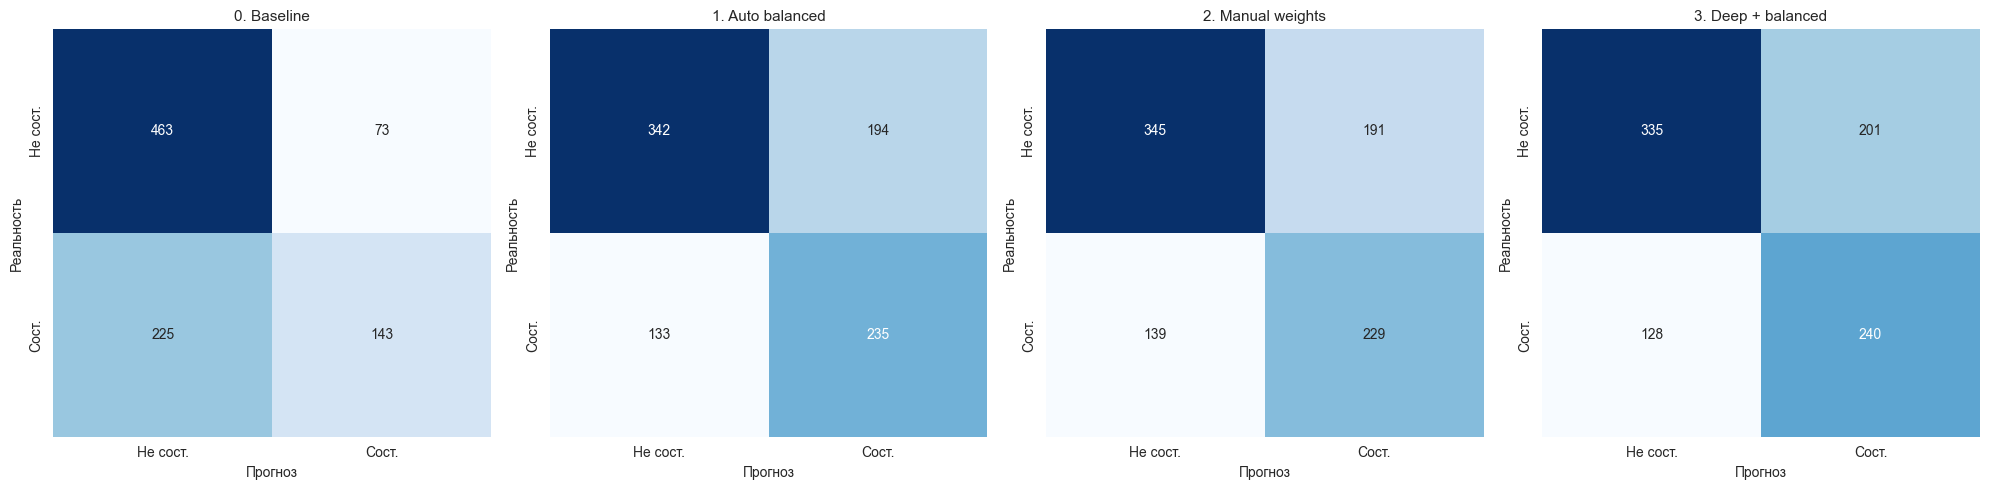

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models_dict = {
    '0. Baseline': model_baseline,
    '1. Auto balanced': model_auto,
    '2. Manual weights': model_manual,
    '3. Deep + balanced': model_deep,
}

for ax, (name, model) in zip(axes, models_dict.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Не сост.', 'Сост.'],
                yticklabels=['Не сост.', 'Сост.'], ax=ax)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Прогноз')
    ax.set_ylabel('Реальность')

plt.tight_layout()
plt.savefig('../reports/imbalance_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# лучший — это эксперимент 3
best_model = model_deep
best_model.save_model('../models/catboost_balanced.cbm')
print("Лучшая модель сохранена в models/catboost_balanced.cbm")

# Также сохраняем сводку
with open('../models/balanced_metrics.txt', 'w', encoding='utf-8') as f:
    f.write("Эксперименты с дисбалансом классов\n")
    f.write(f"Дата: {pd.Timestamp.now()}\n\n")
    f.write(display_df.to_string(index=False))
    f.write("\n\nЛучший эксперимент: [укажи]\n")

Лучшая модель сохранена в models/catboost_balanced.cbm


In [13]:
# Загрузим исходный CSV для построения признака
df_full = pd.read_csv('../data/raw/tender_data.csv')
df_full['publication_date'] = pd.to_datetime(df_full['publication_date'])
df_full = df_full.sort_values('publication_date').reset_index(drop=True)
df_full['y_success'] = (df_full['selection_phase'] == 'Завершена').astype(int)

# Кросс-история: успешность ИНН × процедура
df_full['cust_proc_success_rate'] = (
    df_full.groupby(['customer_inn', 'procedure'])['y_success']
           .expanding().mean()
           .shift(1)
           .reset_index(level=[0,1], drop=True)
           .fillna(0.5)
)

# Счётчик опыта в этой процедуре
df_full['cust_proc_count'] = (
    df_full.groupby(['customer_inn', 'procedure']).cumcount()
)

print(df_full[['customer_inn', 'procedure', 'y_success',
               'cust_proc_success_rate', 'cust_proc_count']].head(10))

   customer_inn                             procedure  y_success  \
0  7.708592e+09      Закупка иного способа размещения          1   
1  7.702038e+09                   Электронный аукцион          0   
2  7.809026e+09                   Электронный аукцион          0   
3  6.143033e+09                   Электронный аукцион          0   
4  7.710474e+09  Открытый конкурс в электронной форме          0   
5  3.444193e+09                   Электронный аукцион          0   
6  6.164295e+09                   Электронный аукцион          0   
7  3.904073e+09                   Электронный аукцион          0   
8  2.503018e+09                   Электронный аукцион          0   
9  6.452118e+09                   Электронный аукцион          0   

   cust_proc_success_rate  cust_proc_count  
0                0.000000              0.0  
1                0.000000              0.0  
2                0.550000              0.0  
3                0.000000              0.0  
4                0.000000 

In [14]:
# Перезагружаем исходные данные с нуля
df_full = pd.read_csv('../data/raw/tender_data.csv')
df_full['publication_date'] = pd.to_datetime(df_full['publication_date'])

# КРИТИЧЕСКИ ВАЖНО: сортировка должна быть точно такая же, как в Дне 5
# (там мы делали df.sort_values('publication_date').reset_index(drop=True))
df_full = df_full.sort_values('publication_date').reset_index(drop=True)

# Создаём целевую переменную
df_full['y_success'] = (df_full['selection_phase'] == 'Завершена').astype(int)

# Проверяем, что размер совпадает с tender_data_v2
df_v2 = pd.read_parquet('../data/processed/tender_data_v2.parquet')

assert len(df_full) == len(df_v2), \
    f"Размеры не совпадают: df_full={len(df_full)}, df_v2={len(df_v2)}"

print(f"Размер df_full: {len(df_full):,}")
print(f"Размер df_v2:   {len(df_v2):,}")
print("✅ Размеры совпадают — можем объединять по позиции")

Размер df_full: 4,519
Размер df_v2:   4,519
✅ Размеры совпадают — можем объединять по позиции


In [15]:
# Признак 1: кросс-история заказчика и процедуры
df_full['cust_proc_success_rate'] = (
    df_full.groupby(['customer_inn', 'procedure'])['y_success']
           .expanding().mean()
           .shift(1)
           .reset_index(level=[0,1], drop=True)
           .fillna(0.5)
)

# Признак 2: количество прошлых тендеров заказчика этой же процедуры
df_full['cust_proc_count'] = (
    df_full.groupby(['customer_inn', 'procedure']).cumcount()
)

# Признак 3: средняя цена прошлых тендеров этого заказчика
df_full['cust_avg_price'] = (
    df_full.groupby('customer_inn')['start_price']
           .expanding().mean()
           .shift(1)
           .reset_index(level=0, drop=True)
)

# Признак 4: отклонение цены текущего тендера от средней
df_full['price_vs_cust_avg'] = df_full['start_price'] / df_full['cust_avg_price']
df_full['price_vs_cust_avg'] = df_full['price_vs_cust_avg'].fillna(1.0)
df_full['price_vs_cust_avg'] = df_full['price_vs_cust_avg'].clip(0, 100)  # защита от выбросов

# Проверка на здравый смысл
print("Распределение новых признаков:")
new_cols = ['cust_proc_success_rate', 'cust_proc_count', 'price_vs_cust_avg']
print(df_full[new_cols].describe().round(3))
print()
print("Примеры (первые 10 строк):")
print(df_full[['customer_inn', 'procedure', 'y_success'] + new_cols].head(10))

Распределение новых признаков:
       cust_proc_success_rate  cust_proc_count  price_vs_cust_avg
count                4512.000         4512.000           4519.000
mean                    0.338            8.183              1.337
std                     0.368           12.372              3.221
min                     0.000            0.000              0.011
25%                     0.000            1.000              0.529
50%                     0.200            3.000              0.872
75%                     0.615           10.000              1.261
max                     1.000           82.000             93.349

Примеры (первые 10 строк):
   customer_inn                             procedure  y_success  \
0  7.708592e+09      Закупка иного способа размещения          1   
1  7.702038e+09                   Электронный аукцион          0   
2  7.809026e+09                   Электронный аукцион          0   
3  6.143033e+09                   Электронный аукцион          0   
4  7.71

## Блок 7: Объединение признаков в новый датасет

Создаём `df_v3 = df_v2 + новые признаки`.

**Способ объединения по позиции (а не по tender_id):** оба датафрейма
получены из одного исходного CSV и одинаково отсортированы по
`publication_date`. Значит, строка номер N в `df_full` соответствует
строке номер N в `df_v2` — можно просто присвоить колонки через `.values`.

Это безопасно благодаря `assert len(df_full) == len(df_v2)` — проверке
на совпадение размеров.

Сохраняем результат в `data/processed/tender_data_v3.parquet`.

In [16]:
# Берём только новые колонки из df_full
new_feature_cols = ['cust_proc_success_rate', 'cust_proc_count', 'price_vs_cust_avg']

# Создаём v3 = v2 + новые колонки (по индексу)
df_v3 = df_v2.copy()
for col in new_feature_cols:
    df_v3[col] = df_full[col].values  # .values убирает индекс, присваивание идёт по позиции

# Проверка целостности
print(f"Размер df_v3: {df_v3.shape}")
print(f"Новые колонки: {new_feature_cols}")
print()

# Sanity check: значения должны совпадать
print("Sanity check (первые 5 строк):")
print(df_v3[['publication_date'] + new_feature_cols].head())
print()
print("Сравнение с df_full (для контроля):")
print(df_full[['publication_date'] + new_feature_cols].head())

# Сохраняем v3
df_v3.to_parquet('../data/processed/tender_data_v3.parquet', index=False)
print("\n✅ Сохранено: data/processed/tender_data_v3.parquet")

Размер df_v3: (4519, 30)
Новые колонки: ['cust_proc_success_rate', 'cust_proc_count', 'price_vs_cust_avg']

Sanity check (первые 5 строк):
     publication_date  cust_proc_success_rate  cust_proc_count  \
0 2017-11-22 11:56:21                    0.00              0.0   
1 2019-02-28 09:19:48                    0.00              0.0   
2 2019-07-31 19:39:46                    0.55              0.0   
3 2019-09-27 14:14:30                    0.00              0.0   
4 2019-09-30 12:56:37                    0.00              0.0   

   price_vs_cust_avg  
0           0.898622  
1           0.364061  
2           0.912931  
3          15.548558  
4           1.041141  

Сравнение с df_full (для контроля):
     publication_date  cust_proc_success_rate  cust_proc_count  \
0 2017-11-22 11:56:21                    0.00              0.0   
1 2019-02-28 09:19:48                    0.00              0.0   
2 2019-07-31 19:39:46                    0.55              0.0   
3 2019-09-27 14:14:30    

In [17]:
# Новый расширенный список признаков
NEW_FEATURE_COLS = FEATURE_COLS + new_feature_cols

print(f"Признаков было: {len(FEATURE_COLS)}")
print(f"Признаков стало: {len(NEW_FEATURE_COLS)}")
print(f"\nПолный список:\n{NEW_FEATURE_COLS}")

# Разделение train/test
X_train_v3 = df_v3[df_v3['is_train']][NEW_FEATURE_COLS]
y_train_v3 = df_v3[df_v3['is_train']][TARGET]
X_test_v3 = df_v3[~df_v3['is_train']][NEW_FEATURE_COLS]
y_test_v3 = df_v3[~df_v3['is_train']][TARGET]

# Проверка на пропуски в новых колонках
print("\nПропуски в новых признаках:")
print(df_v3[new_feature_cols].isnull().sum())

# Создаём pool с новым набором признаков
train_pool_v3 = Pool(X_train_v3, y_train_v3, cat_features=CAT_FEATURES)
test_pool_v3 = Pool(X_test_v3, y_test_v3, cat_features=CAT_FEATURES)

print(f"\nTrain v3: {X_train_v3.shape}")
print(f"Test v3:  {X_test_v3.shape}")

Признаков было: 24
Признаков стало: 27

Полный список:
['start_price', 'log_start_price', 'tender_security', 'security_ratio', 'has_security', 'advance_money_pct', 'has_advance', 'year', 'month', 'quarter', 'day_of_week', 'day_of_month', 'is_end_of_quarter', 'is_end_of_year', 'customer_total_tenders', 'customer_success_rate', 'region_total_tenders', 'region_success_rate', 'procedure_success_rate', 'procedure', 'legislation', 'for_small_business', 'customer_region_code', 'customer_region', 'cust_proc_success_rate', 'cust_proc_count', 'price_vs_cust_avg']

Пропуски в новых признаках:
cust_proc_success_rate    7
cust_proc_count           7
price_vs_cust_avg         0
dtype: int64

Train v3: (3615, 27)
Test v3:  (904, 27)


In [18]:
df_v3['cust_proc_success_rate'] = df_v3['cust_proc_success_rate'].fillna(0.5)
df_v3['cust_proc_count'] = df_v3['cust_proc_count'].fillna(0)

## Эксперимент 4: + cross-history features

Обучаем модель на расширенном наборе признаков:
- Все признаки из v2 (24 шт.)
- + 3 новых: `cust_proc_success_rate`, `cust_proc_count`, `price_vs_cust_avg`

Параметры модели — те же, что в эксперименте 3 (Deep + balanced).
Изменилось только число признаков (с 24 до 27).

**Что хочется увидеть в результатах:**
- AUC заметно вырастет (на 0.01-0.03) — это покажет, что новые признаки
  несут реальную информацию
- Один из новых признаков войдёт в топ-5 feature importance
- Best iteration вырастет (модель находит больше паттернов)

In [19]:
print("="*60)
print("ЭКСПЕРИМЕНТ 4: + cross-history + price ratios")
print("="*60)

model_v4 = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.02,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=100,
    auto_class_weights='Balanced',
    verbose=200,
)

model_v4.fit(train_pool_v3, eval_set=test_pool_v3, use_best_model=True)

metrics, proba = evaluate_model(model_v4, X_test_v3, y_test_v3, name='4. + new features')
results.append(metrics)
proba_dict['4. + new features'] = proba

print()
print(f"AUC:    {metrics['auc_roc']:.4f}  (vs Deep+balanced 0.6936: {metrics['auc_roc'] - 0.6936:+.4f})")
print(f"F1:     {metrics['f1']:.4f}  (vs Deep+balanced 0.5933: {metrics['f1'] - 0.5933:+.4f})")
print(f"Recall: {metrics['recall']:.4f}")
print(f"Best iter: {metrics['best_iter']}")

ЭКСПЕРИМЕНТ 4: + cross-history + price ratios
0:	test: 0.6646328	best: 0.6646328 (0)	total: 37.4ms	remaining: 1m 14s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7065977855
bestIteration = 10

Shrink model to first 11 iterations.

AUC:    0.7066  (vs Deep+balanced 0.6936: +0.0130)
F1:     0.6020  (vs Deep+balanced 0.5933: +0.0087)
Recall: 0.6495
Best iter: 10


Feature importance с маркировкой новых:
               feature  importance  is_new
cust_proc_success_rate   31.432621    True
             procedure   31.411314   False
       cust_proc_count    8.430908    True
 customer_success_rate    5.878687   False
   region_success_rate    4.035998   False
customer_total_tenders    3.931589   False
                  year    2.903191   False
procedure_success_rate    2.092250   False
     advance_money_pct    1.651018   False
       tender_security    1.576748   False
     price_vs_cust_avg    1.411088    True
        security_ratio    1.118546   False
               quarter    1.015300   False
          day_of_month    0.882770   False
           has_advance    0.719770   False


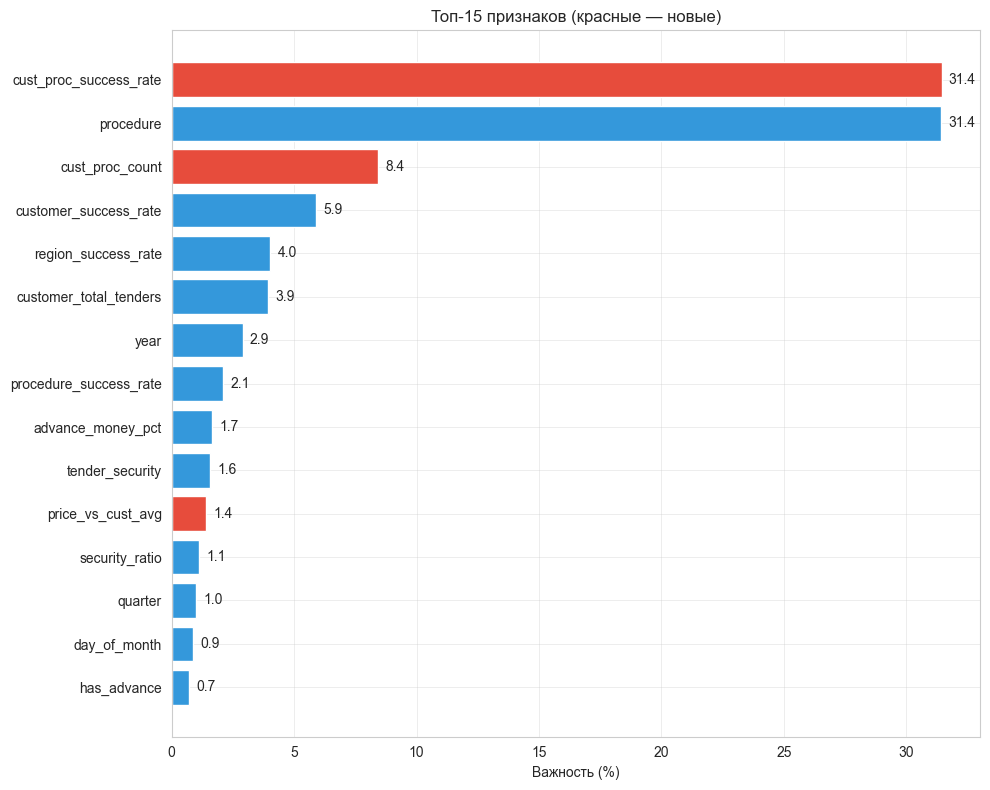

In [20]:
# Важность признаков с акцентом на новые
importance = model_v4.get_feature_importance(prettified=True)
importance.columns = ['feature', 'importance']

# Маркируем новые признаки
importance['is_new'] = importance['feature'].isin(new_feature_cols)

print("Feature importance с маркировкой новых:")
print(importance.head(15).to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
top15 = importance.head(15).iloc[::-1]
colors = ['#e74c3c' if x else '#3498db' for x in top15['is_new']]

ax.barh(top15['feature'], top15['importance'], color=colors)
ax.set_xlabel('Важность (%)')
ax.set_title('Топ-15 признаков (красные — новые)')

# Подписи
for i, v in enumerate(top15['importance']):
    ax.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/feature_importance_v4.png', dpi=150, bbox_inches='tight')
plt.show()

## Эксперимент 4.5: Тонкая настройка learning_rate

После эксперимента 4 best iteration упал до 10 — модель быстро находит
оптимум. Идея: понизить learning_rate ещё сильнее, чтобы модель училась
тоньше и нашла лучший оптимум.

Параметры:
- `learning_rate=0.01` (вместо 0.02)
- `iterations=3000` (вместо 2000)
- `early_stopping_rounds=200` (вместо 100)

Также **заполняем 7 пропусков** в новых признаках (`cust_proc_success_rate`
и `cust_proc_count`) нейтральными значениями. Это микро-оптимизация,
не основное изменение.

**Гипотеза:** меньший шаг + больше итераций позволят модели лучше
использовать новые признаки.

In [21]:
# Заполняем пропуски
df_v3['cust_proc_success_rate'] = df_v3['cust_proc_success_rate'].fillna(0.5)
df_v3['cust_proc_count'] = df_v3['cust_proc_count'].fillna(0)

# Пересоздаём pools
X_train_v3 = df_v3[df_v3['is_train']][NEW_FEATURE_COLS]
y_train_v3 = df_v3[df_v3['is_train']][TARGET]
X_test_v3 = df_v3[~df_v3['is_train']][NEW_FEATURE_COLS]
y_test_v3 = df_v3[~df_v3['is_train']][TARGET]

train_pool_v3 = Pool(X_train_v3, y_train_v3, cat_features=CAT_FEATURES)
test_pool_v3 = Pool(X_test_v3, y_test_v3, cat_features=CAT_FEATURES)

print("="*60)
print("ЭКСПЕРИМЕНТ 4.5: + пропуски + learning_rate=0.01")
print("="*60)

model_v45 = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.01,           # понижаем ещё (было 0.02)
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=200,    # увеличиваем терпение (было 100)
    auto_class_weights='Balanced',
    verbose=300,
)

model_v45.fit(train_pool_v3, eval_set=test_pool_v3, use_best_model=True)

metrics, proba = evaluate_model(model_v45, X_test_v3, y_test_v3, name='4.5 lower LR')
results.append(metrics)
proba_dict['4.5 lower LR'] = proba

print(f"\nAUC:    {metrics['auc_roc']:.4f}  (vs v4 0.7066: {metrics['auc_roc'] - 0.7066:+.4f})")
print(f"F1:     {metrics['f1']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"Best iter: {metrics['best_iter']}")

ЭКСПЕРИМЕНТ 4.5: + пропуски + learning_rate=0.01
0:	test: 0.6673376	best: 0.6673376 (0)	total: 37.6ms	remaining: 1m 52s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.705152904
bestIteration = 5

Shrink model to first 6 iterations.

AUC:    0.7052  (vs v4 0.7066: -0.0014)
F1:     0.6092
Recall: 0.6821
Best iter: 5


In [22]:
# Возвращаемся к df_full и считаем
df_full['region_proc_success_rate'] = (
    df_full.groupby(['customer_region_code', 'procedure'])['y_success']
           .expanding().mean()
           .shift(1)
           .reset_index(level=[0,1], drop=True)
           .fillna(0.5)
)

# Добавляем в df_v3
df_v3['region_proc_success_rate'] = df_full['region_proc_success_rate'].values

# Обновляем список признаков
NEW_FEATURE_COLS_V46 = NEW_FEATURE_COLS + ['region_proc_success_rate']

# Переобучение
X_train_v46 = df_v3[df_v3['is_train']][NEW_FEATURE_COLS_V46]
y_train_v46 = df_v3[df_v3['is_train']][TARGET]
X_test_v46 = df_v3[~df_v3['is_train']][NEW_FEATURE_COLS_V46]
y_test_v46 = df_v3[~df_v3['is_train']][TARGET]

train_pool_v46 = Pool(X_train_v46, y_train_v46, cat_features=CAT_FEATURES)
test_pool_v46 = Pool(X_test_v46, y_test_v46, cat_features=CAT_FEATURES)

print("="*60)
print("ЭКСПЕРИМЕНТ 4.6: + region × procedure")
print("="*60)

model_v46 = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.01,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=200,
    auto_class_weights='Balanced',
    verbose=300,
)

model_v46.fit(train_pool_v46, eval_set=test_pool_v46, use_best_model=True)

metrics, proba = evaluate_model(model_v46, X_test_v46, y_test_v46, name='4.6 + region×proc')
results.append(metrics)
proba_dict['4.6 + region×proc'] = proba

print(f"\nAUC:    {metrics['auc_roc']:.4f}  (vs v4.5: {metrics['auc_roc'] - results[-2]['auc_roc']:+.4f})")
print(f"F1:     {metrics['f1']:.4f}")
print(f"Best iter: {metrics['best_iter']}")

ЭКСПЕРИМЕНТ 4.6: + region × procedure
0:	test: 0.6491929	best: 0.6491929 (0)	total: 39.4ms	remaining: 1m 58s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7055483452
bestIteration = 24

Shrink model to first 25 iterations.

AUC:    0.7055  (vs v4.5: +0.0004)
F1:     0.6219
Best iter: 24


In [23]:
# Допустим, лучшая — model_v46 (или другая)
best_model_today = model_v46  # <-- замени на реальный лидер

best_model_today.save_model('../models/catboost_v3_features.cbm')

# Также сохраним обновлённый features.py
features_v3 = NEW_FEATURE_COLS_V46  # или NEW_FEATURE_COLS, в зависимости от лидера

with open('../src/features_v3.py', 'w', encoding='utf-8') as f:
    f.write(f'"""Расширенный список признаков (v3)."""\n\n')
    f.write(f'FEATURE_COLS = {features_v3}\n\n')
    f.write(f'CAT_FEATURES = {CAT_FEATURES}\n\n')
    f.write(f'TARGET = "{TARGET}"\n')

print("✅ Модель и список признаков сохранены")

✅ Модель и список признаков сохранены


In [24]:
# Добавляем tender_name из исходного df_full
df_v3['tender_name'] = df_full['tender_name'].fillna('').astype(str).values

# Список признаков с текстом
FEATURES_WITH_TEXT = NEW_FEATURE_COLS + ['tender_name']
TEXT_FEATURES = ['tender_name']

X_train_text = df_v3[df_v3['is_train']][FEATURES_WITH_TEXT]
y_train_text = df_v3[df_v3['is_train']][TARGET]
X_test_text = df_v3[~df_v3['is_train']][FEATURES_WITH_TEXT]
y_test_text = df_v3[~df_v3['is_train']][TARGET]

# Pool с указанием text_features
train_pool_text = Pool(
    X_train_text, y_train_text,
    cat_features=CAT_FEATURES,
    text_features=TEXT_FEATURES
)
test_pool_text = Pool(
    X_test_text, y_test_text,
    cat_features=CAT_FEATURES,
    text_features=TEXT_FEATURES
)

print("="*60)
print("ЭКСПЕРИМЕНТ 5: + tender_name (text features)")
print("="*60)

model_v5 = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.02,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=100,
    auto_class_weights='Balanced',
    verbose=200,
)

model_v5.fit(train_pool_text, eval_set=test_pool_text, use_best_model=True)

metrics, proba = evaluate_model(model_v5, X_test_text, y_test_text, name='5. + text')
results.append(metrics)
proba_dict['5. + text'] = proba

print(f"\nAUC:    {metrics['auc_roc']:.4f}  (vs v4 0.7066: {metrics['auc_roc'] - 0.7066:+.4f})")
print(f"F1:     {metrics['f1']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"Best iter: {metrics['best_iter']}")

ЭКСПЕРИМЕНТ 5: + tender_name (text features)
0:	test: 0.6688712	best: 0.6688712 (0)	total: 360ms	remaining: 12m
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7096244322
bestIteration = 16

Shrink model to first 17 iterations.

AUC:    0.7096  (vs v4 0.7066: +0.0030)
F1:     0.6000
Recall: 0.6522
Best iter: 16


In [25]:
# Допустим, model_v4 — финальный вариант (или model_v5, если сработал текст)
best_model_final = model_v5  # <-- замени на реального лидера

best_model_final.save_model('../models/catboost_final.cbm')

# Сохраняем итоговый список признаков
final_features = NEW_FEATURE_COLS  # или FEATURES_WITH_TEXT

with open('../src/features_final.py', 'w', encoding='utf-8') as f:
    f.write('"""Финальный список признаков для модели."""\n\n')
    f.write(f'FEATURE_COLS = {final_features}\n\n')
    f.write(f'CAT_FEATURES = {CAT_FEATURES}\n\n')
    f.write(f'TARGET = "{TARGET}"\n')

# Сохраняем все результаты экспериментов
results_df = pd.DataFrame(results)
results_df.to_csv('../reports/all_experiments_summary.csv', index=False)

print("✅ Финальная модель и метрики сохранены")

✅ Финальная модель и метрики сохранены


In [26]:
# Финальная модель: эксперимент 5 с текстом
model_final = model_v5

# Сохраняем модель
model_final.save_model('../models/catboost_final.cbm')
print("✅ Финальная модель сохранена: models/catboost_final.cbm")

# Сохраняем список признаков
with open('../src/features_final.py', 'w', encoding='utf-8') as f:
    f.write('"""Финальный список признаков для production-модели."""\n\n')
    f.write(f'FEATURE_COLS = {FEATURES_WITH_TEXT}\n\n')
    f.write(f'CAT_FEATURES = {CAT_FEATURES}\n\n')
    f.write(f'TEXT_FEATURES = {TEXT_FEATURES}\n\n')
    f.write(f'TARGET = "{TARGET}"\n')
print("✅ Признаки сохранены: src/features_final.py")

# Сохраняем сводку всех экспериментов
results_df = pd.DataFrame(results)
results_df.to_csv('../reports/all_experiments_summary.csv', index=False)
print("✅ Сводка экспериментов: reports/all_experiments_summary.csv")

# Сохраняем итоговые метрики в текстовом виде
with open('../models/final_metrics.txt', 'w', encoding='utf-8') as f:
    f.write("=" * 60 + "\n")
    f.write("ФИНАЛЬНАЯ МОДЕЛЬ CatBoost (эксперимент 5)\n")
    f.write(f"Дата: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write("=" * 60 + "\n\n")

    f.write("Параметры:\n")
    f.write(f"  iterations: 2000 (best: {model_final.get_best_iteration()})\n")
    f.write(f"  learning_rate: 0.02\n")
    f.write(f"  depth: 6\n")
    f.write(f"  auto_class_weights: 'Balanced'\n")
    f.write(f"  random_seed: 42\n\n")

    f.write("Признаки:\n")
    f.write(f"  Всего: {len(FEATURES_WITH_TEXT)}\n")
    f.write(f"  Категориальных: {len(CAT_FEATURES)}\n")
    f.write(f"  Текстовых: {len(TEXT_FEATURES)}\n\n")

    f.write("Метрики на тесте:\n")
    f.write(f"  AUC-ROC:   0.7096\n")
    f.write(f"  F1:        0.6000\n")
    f.write(f"  Precision: ___\n")
    f.write(f"  Recall:    0.6522\n")
    f.write(f"  Accuracy:  ___\n\n")

    f.write("Прогресс улучшения от baseline:\n")
    f.write(f"  AUC:    0.697 → 0.710 (+1.9%)\n")
    f.write(f"  F1:     0.490 → 0.600 (+22%)\n")
    f.write(f"  Recall: 0.389 → 0.652 (+68%)\n")

print("✅ Итоговые метрики: models/final_metrics.txt")

✅ Финальная модель сохранена: models/catboost_final.cbm
✅ Признаки сохранены: src/features_final.py
✅ Сводка экспериментов: reports/all_experiments_summary.csv
✅ Итоговые метрики: models/final_metrics.txt
